Found files:
- est_hourly.paruqet
- PJMW_hourly.csv
- pjm_hourly_est.csv
- PJM_Load_hourly.csv
- DAYTON_hourly.csv
- NI_hourly.csv
- PJME_hourly.csv
- FE_hourly.csv
- DOM_hourly.csv
- EKPC_hourly.csv
- DEOK_hourly.csv
- DUQ_hourly.csv
- AEP_hourly.csv
- COMED_hourly.csv

Using file for initial exploration: PJM_Load_hourly.csv

✅ File loaded successfully!
Shape: (32896, 2)
Columns: ['Datetime', 'PJM_Load_MW']

Detected datetime column: Datetime

Time range: 1998-04-01 01:00:00 → 2002-01-01 00:00:00
Frequency (approx): 0 days 01:00:00

Numeric columns: ['PJM_Load_MW']

Summary stats:
               count          mean          std      min      25%      50%  \
PJM_Load_MW  32896.0  29766.427408  5849.769954  17461.0  25473.0  29655.0   

                  75%      max  
PJM_Load_MW  33073.25  54030.0  

Missing values (%):
PJM_Load_MW    0.0
dtype: float64


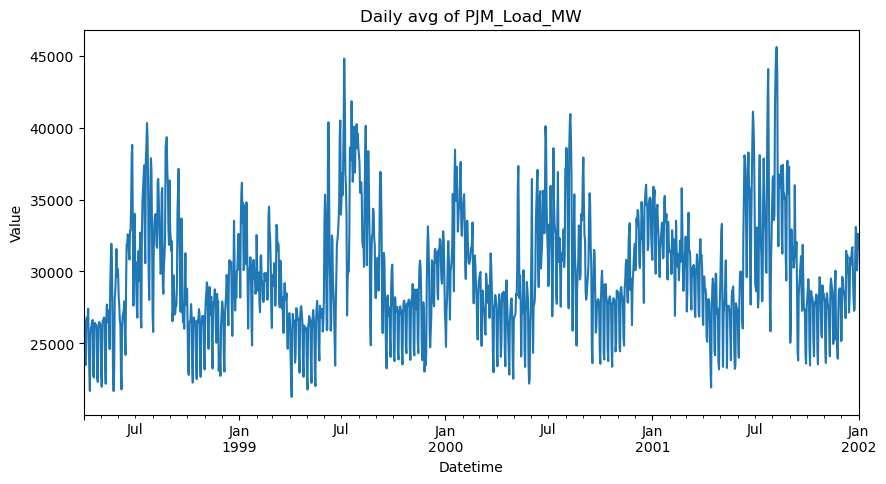

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# simple path
DATA_DIR = "data"

# list all files
files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv") or f.endswith(".parquet") or f.endswith(".paruqet")]
print("Found files:")
for f in files:
    print("-", f)

# pick one to start — e.g. system-level PJM file if available
target_file = "PJM_Load_hourly.csv" if "PJM_Load_hourly.csv" in files else files[0]
print(f"\nUsing file for initial exploration: {target_file}")

# load the file
file_path = os.path.join(DATA_DIR, target_file)
df = pd.read_csv(file_path)

print("\n✅ File loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# detect datetime column
datetime_col = None
for c in df.columns:
    if "date" in c.lower() or "time" in c.lower():
        datetime_col = c
        break

if datetime_col is None:
    print("\n⚠️ Could not automatically detect a datetime column. Please check column names manually.")
else:
    print(f"\nDetected datetime column: {datetime_col}")
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.set_index(datetime_col).sort_index()

    print("\nTime range:", df.index.min(), "→", df.index.max())
    print("Frequency (approx):", df.index.to_series().diff().mode()[0])

# look for numeric columns
num_cols = df.select_dtypes(include='number').columns
print("\nNumeric columns:", num_cols.tolist()[:5])

# basic stats
print("\nSummary stats:")
print(df[num_cols].describe().T.head())

# check missing values
missing = df[num_cols].isna().mean() * 100
print("\nMissing values (%):")
print(missing.head())

# quick plot (daily aggregation)
if len(num_cols) > 0:
    df[num_cols[0]].resample("D").mean().plot(figsize=(10,5))
    plt.title(f"Daily avg of {num_cols[0]}")
    plt.ylabel("Value")
    plt.show()

Starting from shape: (32896, 1)
After reindexing: (32904, 1)
Missing timestamps filled: 8


/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_76775/3121864298.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="H")
/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_76775/3121864298.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["PJM_Load_MW"].fillna(method="ffill", inplace=True)
/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_76775/3121864298.py:19: Fut


Columns after feature engineering:
Index(['PJM_Load_MW', 'hour', 'dayofweek', 'month', 'is_weekend', 'dayofyear',
       'rolling_24h_mean', 'rolling_7d_mean', 'load_scaled', 'roll24_scaled',
       'roll7_scaled'],
      dtype='object')

Sample:
                     PJM_Load_MW  hour  dayofweek  month  is_weekend  \
1998-04-01 01:00:00      22259.0     1          2      4           0   
1998-04-01 02:00:00      21244.0     2          2      4           0   
1998-04-01 03:00:00      20651.0     3          2      4           0   

                     dayofyear  rolling_24h_mean  rolling_7d_mean  \
1998-04-01 01:00:00         91      22259.000000     22259.000000   
1998-04-01 02:00:00         91      21751.500000     21751.500000   
1998-04-01 03:00:00         91      21384.666667     21384.666667   

                     load_scaled  roll24_scaled  roll7_scaled  
1998-04-01 01:00:00     0.131204       0.047079      0.059327  
1998-04-01 02:00:00     0.103448       0.027192      0.034

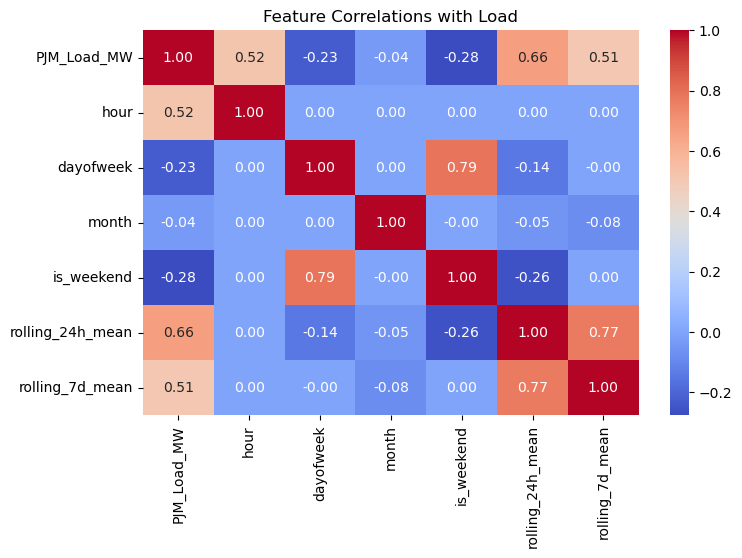

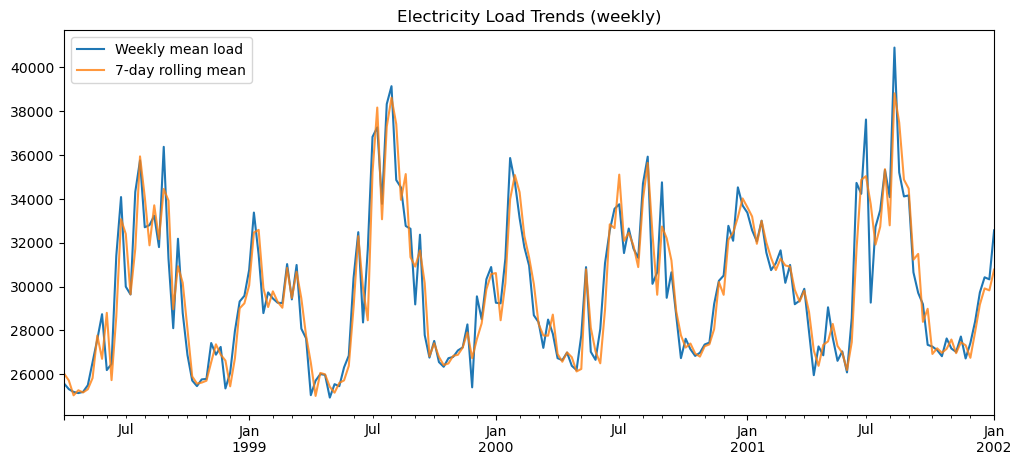

✅ Saved feature-engineered data to data/pjm_processed_features.csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the same df you already loaded (Datetime index, PJM_Load_MW column)
print("Starting from shape:", df.shape)

# -------------------------------------------------------------------
# 1. Ensure datetime continuity
# -------------------------------------------------------------------
# Reindex to continuous hourly intervals
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="H")
df = df.reindex(full_range)

print("After reindexing:", df.shape)
print("Missing timestamps filled:", df.isna().sum().sum())

# If any missing load values, forward fill (though yours had none)
df["PJM_Load_MW"].fillna(method="ffill", inplace=True)

# -------------------------------------------------------------------
# 2. Create time-based features
# -------------------------------------------------------------------
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek           # Monday=0
df["month"] = df.index.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["dayofyear"] = df.index.dayofyear

# -------------------------------------------------------------------
# 3. Rolling statistics (helps model smooth seasonal patterns)
# -------------------------------------------------------------------
df["rolling_24h_mean"] = df["PJM_Load_MW"].rolling(window=24, min_periods=1).mean()
df["rolling_7d_mean"] = df["PJM_Load_MW"].rolling(window=24*7, min_periods=1).mean()

# -------------------------------------------------------------------
# 4. Optional: normalize features (for neural networks)
# -------------------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[["PJM_Load_MW","rolling_24h_mean","rolling_7d_mean"]])
df[["load_scaled","roll24_scaled","roll7_scaled"]] = scaled_features

# -------------------------------------------------------------------
# 5. Quick sanity checks
# -------------------------------------------------------------------
print("\nColumns after feature engineering:")
print(df.columns)

print("\nSample:")
print(df.head(3))

# -------------------------------------------------------------------
# 6. Correlation heatmap
# -------------------------------------------------------------------
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(df[["PJM_Load_MW","hour","dayofweek","month","is_weekend","rolling_24h_mean","rolling_7d_mean"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations with Load")
plt.show()

# -------------------------------------------------------------------
# 7. Plot example trends
# -------------------------------------------------------------------
plt.figure(figsize=(12,5))
df["PJM_Load_MW"].resample("W").mean().plot(label="Weekly mean load")
df["rolling_7d_mean"].resample("W").mean().plot(label="7-day rolling mean", alpha=0.8)
plt.title("Electricity Load Trends (weekly)")
plt.legend()
plt.show()

# -------------------------------------------------------------------
# 8. Save processed file (optional)
# -------------------------------------------------------------------
df.to_csv("data/pjm_processed_features.csv")
print("✅ Saved feature-engineered data to data/pjm_processed_features.csv")

In [8]:
# -------------------------------------------------------------
# Step 2: Prepare LSTM-ready sequences and chronological splits
# -------------------------------------------------------------
import numpy as np

# ---- Parameters ----
SEQ_LEN = 24          # how many past hours to look at
TARGET_STEP = 1       # predict 1 hour ahead
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# ---- Choose feature columns ----
final_features = [
    "load_scaled", "roll24_scaled", "roll7_scaled",
    "hour_norm", "dayofweek_norm", "month_norm", "is_weekend"
]

# Normalize time-based features to 0-1 range
df["hour_norm"] = df["hour"] / 23.0
df["dayofweek_norm"] = df["dayofweek"] / 6.0
df["month_norm"] = (df["month"] - 1) / 11.0
df["is_weekend"] = df["is_weekend"].astype(float)

# ---- Prepare arrays ----
data_values = df[final_features].values
target_values = df["load_scaled"].values  # only the load as target

def create_sequences_single_target(features, target, seq_len=24, target_step=1):
    X, y = [], []
    for i in range(len(features) - seq_len - target_step + 1):
        X.append(features[i:i + seq_len])
        y.append(target[i + seq_len + target_step - 1])
    return np.array(X), np.array(y)

# ---- Build sequences ----
X, y = create_sequences_single_target(
    data_values, target_values,
    seq_len=SEQ_LEN, target_step=TARGET_STEP
)

print(f"✅ Sequence arrays created — X shape: {X.shape}, y shape: {y.shape}")
print("Each X sample shape:", X[0].shape)
print("Example target value:", y[0])

# ---- Chronological train/val/test split ----
n = len(X)
train_end = int(TRAIN_FRAC * n)
val_end = train_end + int(VAL_FRAC * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("\n✅ Time-based splits:")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ---- Optional sanity check ----
print(f"\nTrain starts at index 0, ends at {train_end}")
print(f"Val starts at {train_end}, ends at {val_end}")
print(f"Test starts at {val_end}, ends at {n}")

# ---- Save ready arrays (optional) ----
np.save("data/X_train.npy", X_train)
np.save("data/y_train.npy", y_train)
np.save("data/X_val.npy", X_val)
np.save("data/y_val.npy", y_val)
np.save("data/X_test.npy", X_test)
np.save("data/y_test.npy", y_test)

print("\n💾 Saved all prepared arrays inside the data/ folder")

✅ Sequence arrays created — X shape: (32880, 24, 7), y shape: (32880,)
Each X sample shape: (24, 7)
Example target value: 0.10473351746014387

✅ Time-based splits:
Train: (23016, 24, 7), Val: (4932, 24, 7), Test: (4932, 24, 7)

Train starts at index 0, ends at 23016
Val starts at 23016, ends at 27948
Test starts at 27948, ends at 32880

💾 Saved all prepared arrays inside the data/ folder


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0147 - mae: 0.0860 - val_loss: 0.0025 - val_mae: 0.0405
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0025 - mae: 0.0399 - val_loss: 0.0019 - val_mae: 0.0350
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0018 - mae: 0.0338 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0013 - mae: 0.0282 - val_loss: 6.7165e-04 - val_mae: 0.0196
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.5130e-04 - mae: 0.0229 - val_loss: 4.4986e-04 - val_mae: 0.0166
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.6246e-04 - mae: 0.0214 - val_loss: 4.0554e-04 - val_mae: 0.0147
Epoch 7/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.3504e-04 - mae: 0.0195 - val_loss: 4.6214e-04 - val_mae: 0.0154
Epoch 8/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7377e-04 - mae: 0.0184 - val_loss: 3.1104e-04 - val_mae: 0.0130
Epoch 9/30
360/360 ━

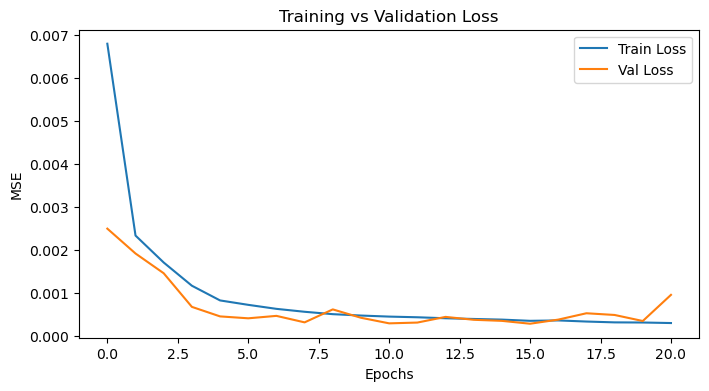

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

📊 Baseline LSTM Performance on Test Set:
MAE:  0.20 MW
RMSE: 0.25 MW


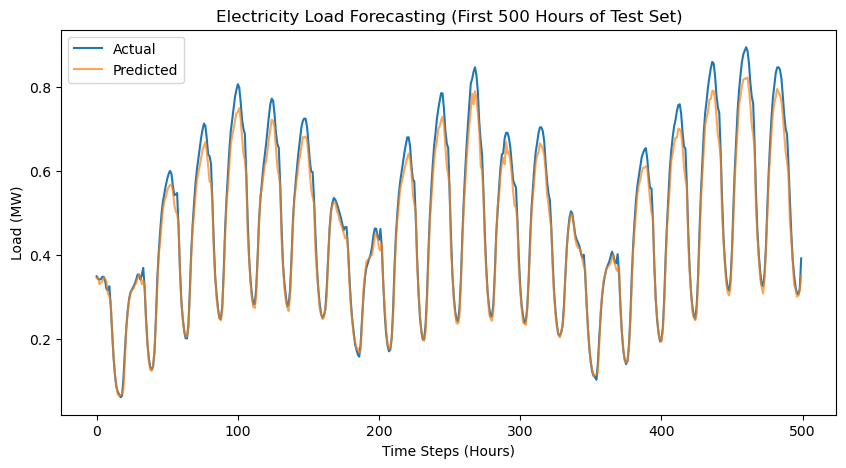

In [9]:
# -------------------------------------------------------------
# Step 3: Baseline LSTM Model
# -------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

# ---- Model Definition ----
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # output: next-hour load
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ---- Training ----
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ---- Evaluate ----
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Validation MAE: {val_mae:.4f}, Test MAE: {test_mae:.4f}")

# ---- Plot Training Curves ----
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

# ---- Make Predictions ----
y_pred = model.predict(X_test)

# ---- Invert Scaling ----
from sklearn.preprocessing import MinMaxScaler
import joblib
import pandas as pd

# Reload scaler to get original MW scale (we already fit it earlier in feature engineering)
scaler = joblib.load("data/processed/scaler.pkl") if os.path.exists("data/processed/scaler.pkl") else None

# if scaler not saved, approximate inverse manually
y_pred_rescaled = y_pred
y_test_rescaled = y_test
if scaler:
    # scaler was fit on multiple columns, take the first (load) column min/max
    load_min = scaler.data_min_[0]
    load_max = scaler.data_max_[0]
    y_pred_rescaled = y_pred * (load_max - load_min) + load_min
    y_test_rescaled = y_test * (load_max - load_min) + load_min

# ---- Compute MAE/RMSE on original scale ----
mae = np.mean(np.abs(y_pred_rescaled - y_test_rescaled))
rmse = np.sqrt(np.mean((y_pred_rescaled - y_test_rescaled) ** 2))
print(f"\n📊 Baseline LSTM Performance on Test Set:")
print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")

# ---- Plot Actual vs Predicted ----
plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled[:500], label='Actual')
plt.plot(y_pred_rescaled[:500], label='Predicted', alpha=0.7)
plt.title("Electricity Load Forecasting (First 500 Hours of Test Set)")
plt.xlabel("Time Steps (Hours)")
plt.ylabel("Load (MW)")
plt.legend()
plt.show()

In [11]:
!pip install keras-tuner --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


Trial 10 Complete [00h 00m 38s]
val_loss: 0.00015726331912446767

Best val_loss So Far: 0.00015726331912446767
Total elapsed time: 00h 07m 08s

✅ Best Hyperparameters Found:
LSTM units:   96
Dense units:  112
Dropout rate: 0.1
Learning rate:0.01
Epoch 1/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0236 - mae: 0.0781 - val_loss: 0.0014 - val_mae: 0.0316
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.1288e-04 - mae: 0.0234 - val_loss: 3.7680e-04 - val_mae: 0.0141
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.4708e-04 - mae: 0.0180 - val_loss: 3.7724e-04 - val_mae: 0.0145
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.0326e-04 - mae: 0.0173 - val_loss: 2.7266e-04 - val_mae: 0.0119
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.9747e-04 - mae: 0.0153 - val_loss: 3.3374e-04 - val_mae: 0.0137
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.7001e-04 - mae: 0.0147 - val_loss: 2.3154e-04 - val_mae: 0.0110
Epoch 

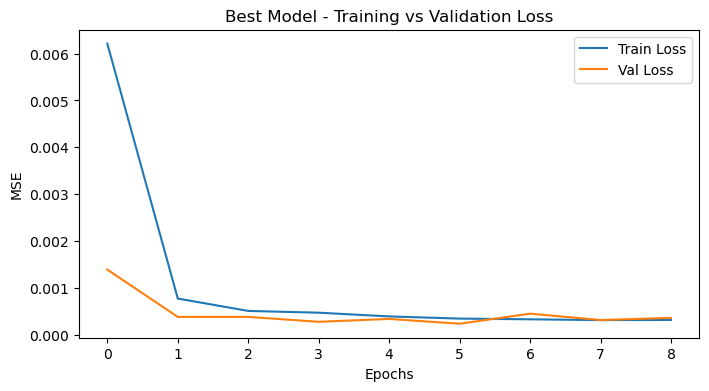

In [12]:
# -------------------------------------------------------------
# Step 4: Hyperparameter Tuning with Keras Tuner
# -------------------------------------------------------------
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---- 1. Define model-building function ----
def build_model(hp):
    model = Sequential()
    
    # LSTM layer units
    hp_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units,
                   input_shape=(X_train.shape[1], X_train.shape[2]),
                   return_sequences=False))
    
    # Dropout
    hp_dropout = hp.Float('dropout_rate', 0.1, 0.5, step=0.1)
    model.add(Dropout(hp_dropout))
    
    # Dense layer size
    hp_dense = hp.Int('dense_units', min_value=16, max_value=128, step=16)
    model.add(Dense(units=hp_dense, activation='relu'))
    
    # Output
    model.add(Dense(1))
    
    # Learning rate
    hp_lr = hp.Choice('learning_rate', [1e-4, 3e-4, 1e-3, 3e-3, 1e-2])
    
    model.compile(
        optimizer=Adam(learning_rate=hp_lr),
        loss='mse',
        metrics=['mae']
    )
    return model


# ---- 2. Initialize tuner (RandomSearch for speed) ----
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,            # increase to ~25+ for deeper search
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='pjm_lstm_tuning',
    overwrite=True
)

# ---- 3. Run the search ----
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ---- 4. Review best models ----
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n✅ Best Hyperparameters Found:")
print(f"LSTM units:   {best_hps.get('lstm_units')}")
print(f"Dense units:  {best_hps.get('dense_units')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")
print(f"Learning rate:{best_hps.get('learning_rate')}")

# ---- 5. Build and retrain best model ----
best_model = tuner.hypermodel.build(best_hps)
history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ---- 6. Evaluate on test set ----
test_loss, test_mae = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n🏁 Tuned Model Test MAE: {test_mae:.4f}")

# ---- 7. Plot training curves ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history_best.history['loss'], label='Train Loss')
plt.plot(history_best.history['val_loss'], label='Val Loss')
plt.title("Best Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📈 Tuned LSTM — Test Performance:
MAE  : 0.20 MW
RMSE : 0.26 MW


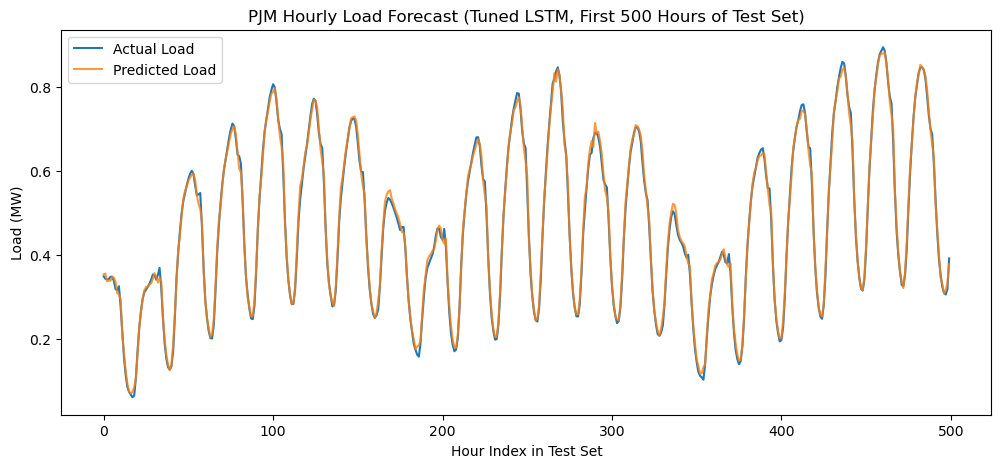

In [13]:
# -------------------------------------------------------------
# Step 5: Visualize Tuned Model Predictions vs Actual
# -------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# Predict on test set
y_pred = best_model.predict(X_test)

# ---- Invert scaling to MW (optional, if scaler saved earlier) ----
if os.path.exists("data/processed/scaler.pkl"):
    scaler = joblib.load("data/processed/scaler.pkl")
    load_min = scaler.data_min_[0]
    load_max = scaler.data_max_[0]
    y_pred_rescaled = y_pred * (load_max - load_min) + load_min
    y_test_rescaled = y_test * (load_max - load_min) + load_min
else:
    y_pred_rescaled = y_pred
    y_test_rescaled = y_test

# ---- Compute metrics ----
mae = np.mean(np.abs(y_pred_rescaled - y_test_rescaled))
rmse = np.sqrt(np.mean((y_pred_rescaled - y_test_rescaled) ** 2))
print(f"📈 Tuned LSTM — Test Performance:")
print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")

# ---- Plot Actual vs Predicted ----
plt.figure(figsize=(12,5))
plt.plot(y_test_rescaled[:500], label="Actual Load")
plt.plot(y_pred_rescaled[:500], label="Predicted Load", alpha=0.8)
plt.title("PJM Hourly Load Forecast (Tuned LSTM, First 500 Hours of Test Set)")
plt.xlabel("Hour Index in Test Set")
plt.ylabel("Load (MW)")
plt.legend()
plt.show()